In [9]:
import pandas as pd

df = pd.read_csv('digital_media_cleaned.csv')

print("--- Missing Values ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

print("\n--- Data Types and Non-Null Counts ---")
print(df.info())

print("\n--- Basic Statistics ---")
print(df.describe())

--- Missing Values ---
campaign_id             0
date                    0
channel                 0
region                  0
device_type             0
audience_segment        0
campaign_objective      0
impressions             0
clicks                  0
ctr_pct                 0
spend_usd               0
conversions             0
conversion_rate_pct     0
bounce_rate_pct         0
session_duration_sec    0
audience_age            0
ad_quality_score        0
revenue_usd             0
dtype: int64

Total Duplicate Rows: 0

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2397 entries, 0 to 2396
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   campaign_id           2397 non-null   object 
 1   date                  2397 non-null   object 
 2   channel               2397 non-null   object 
 3   region                2397 non-null   object 
 4   device_type  

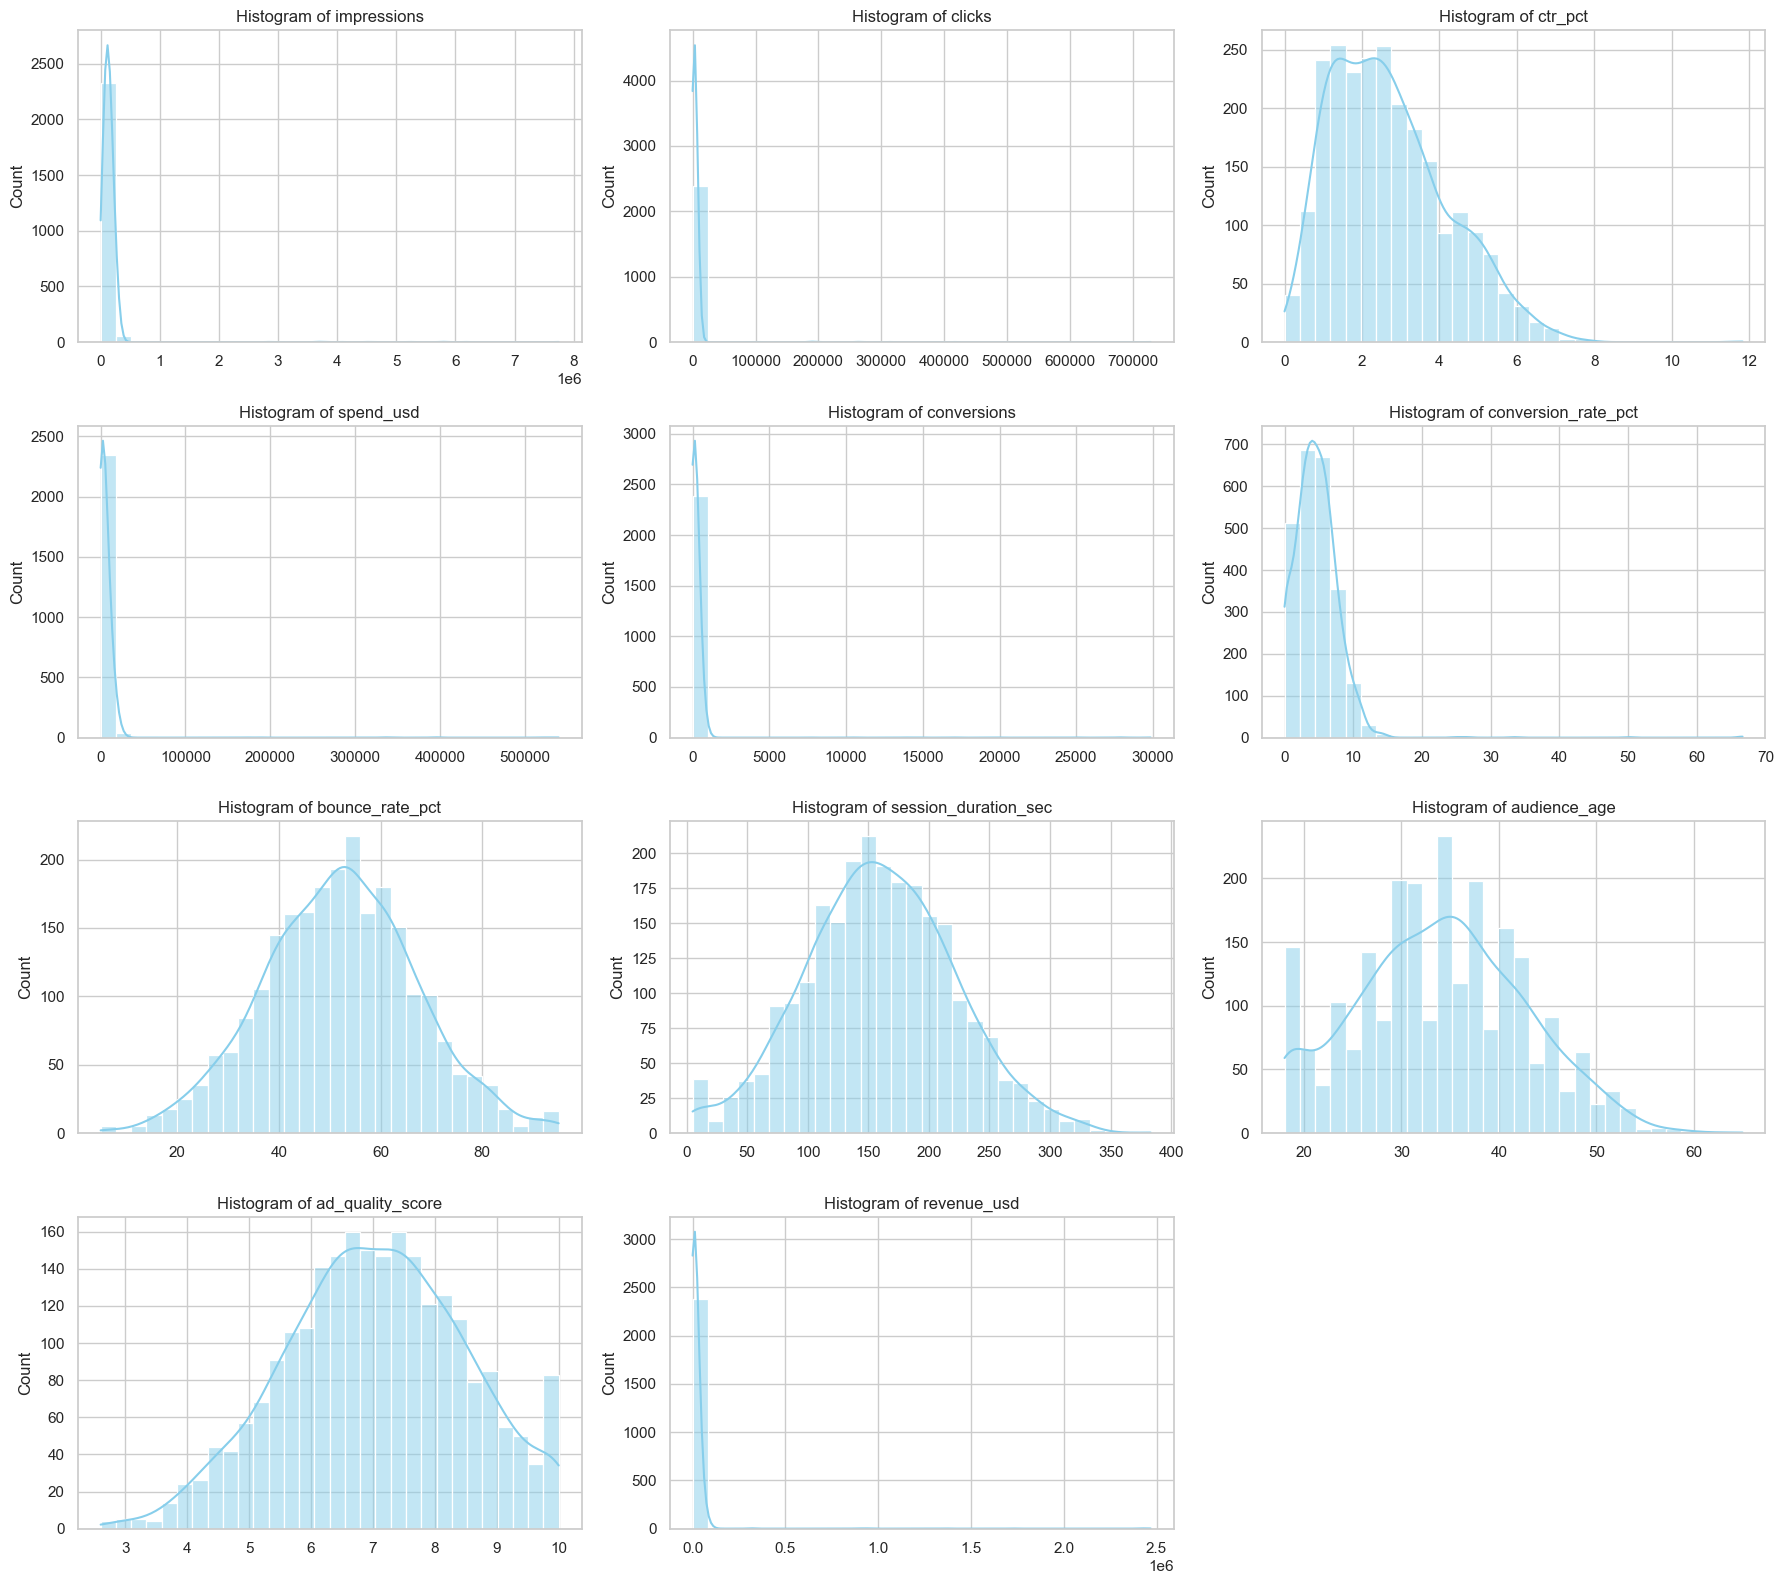

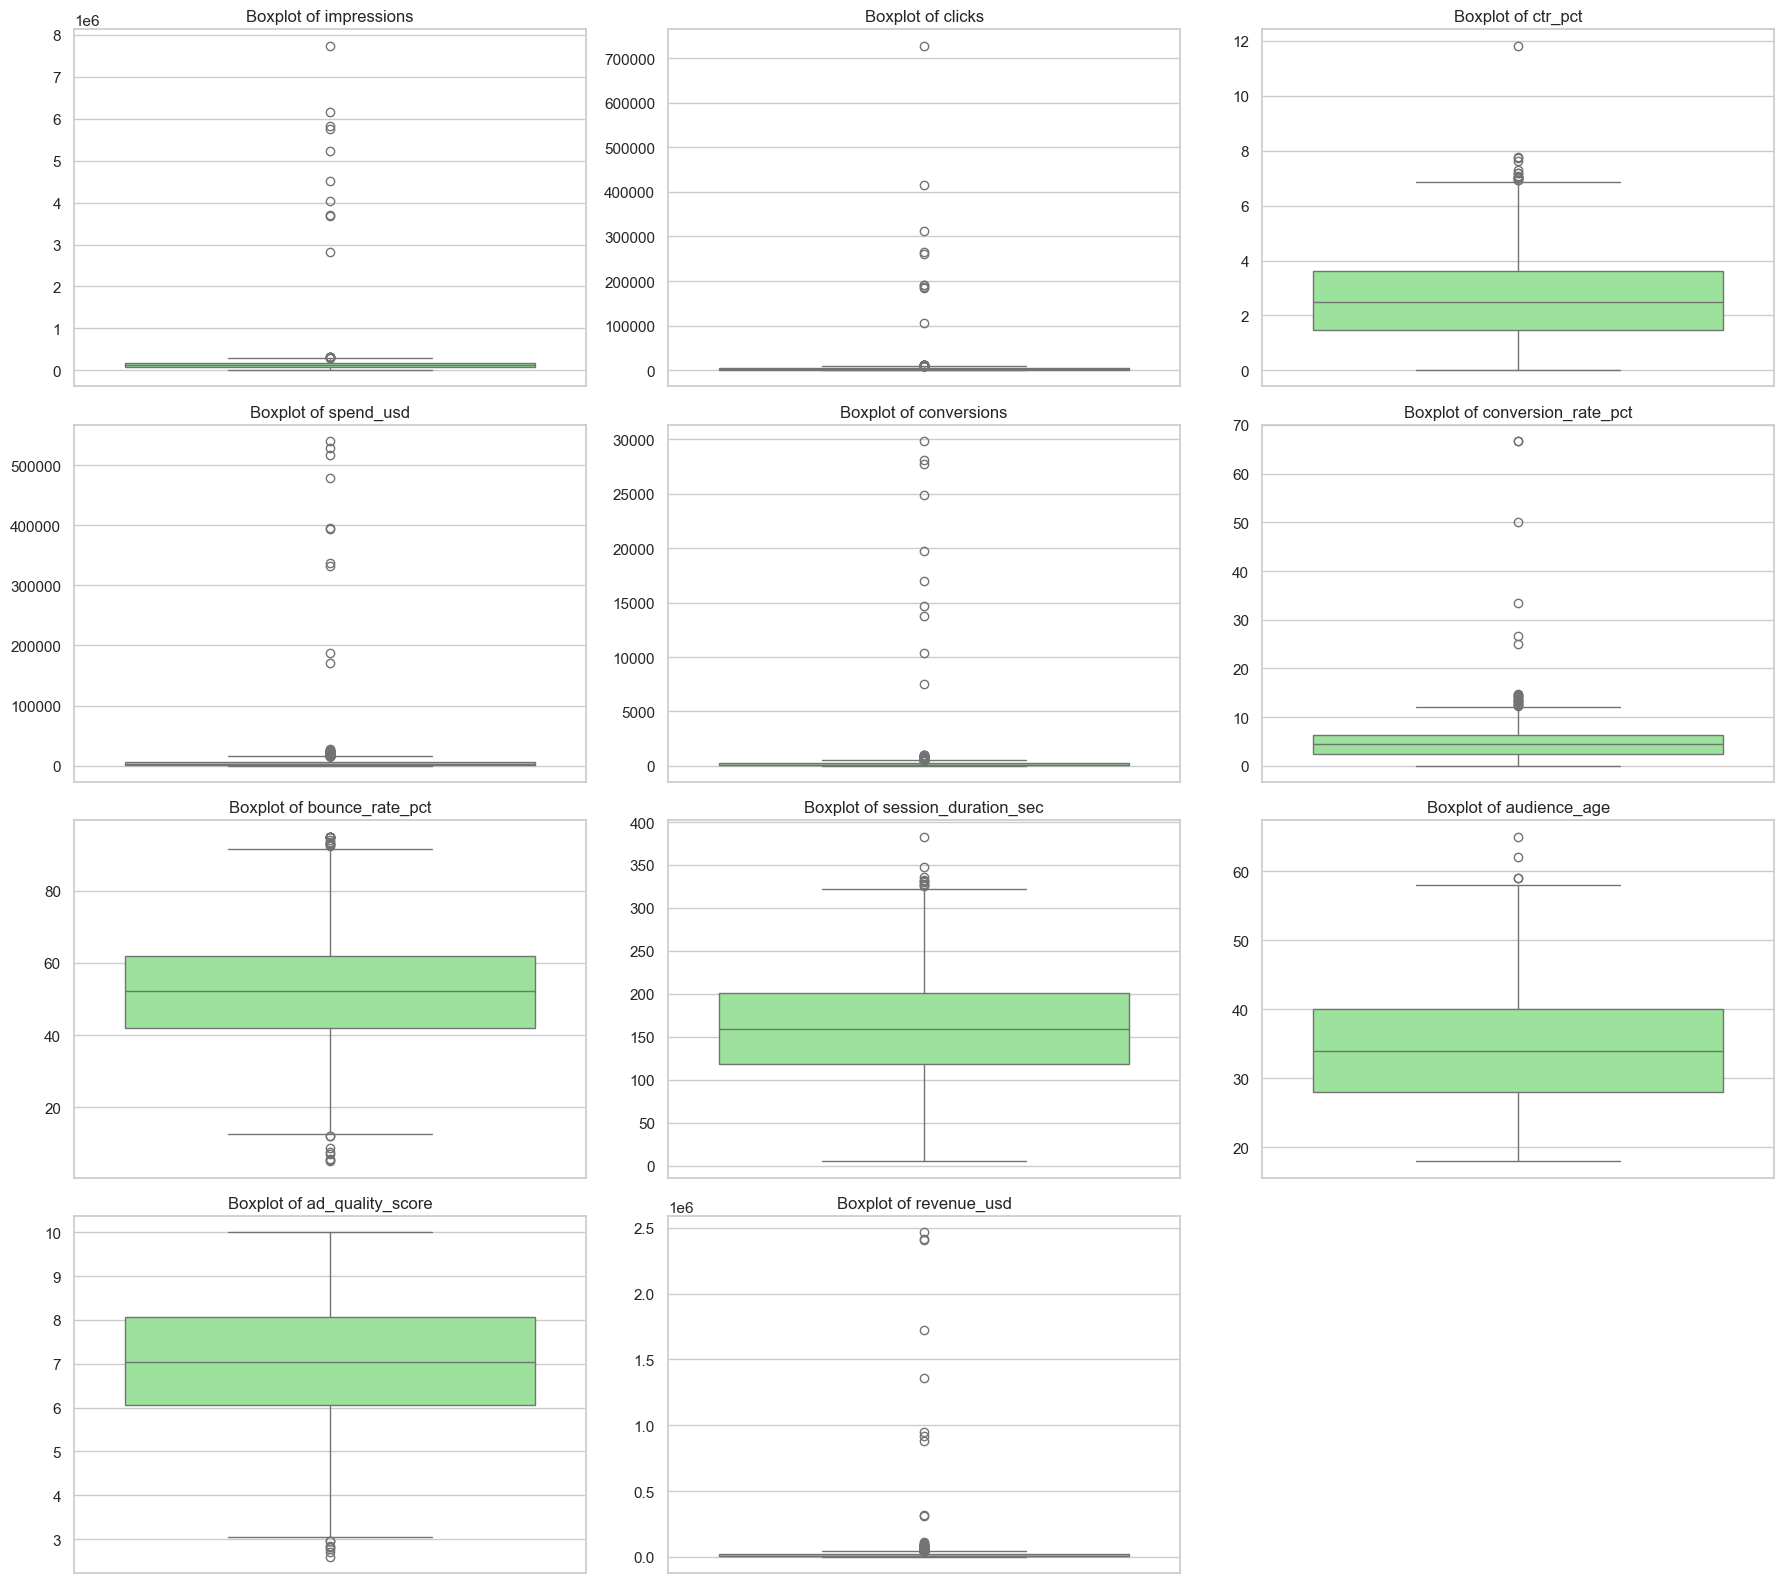

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('digital_media_cleaned.csv')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='skyblue', bins=30)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\Saquire\AppData\Local\Temp\ipykernel_23620\4112217425.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='channel', y=performance_metric, data=channel_perf, palette='viridis')


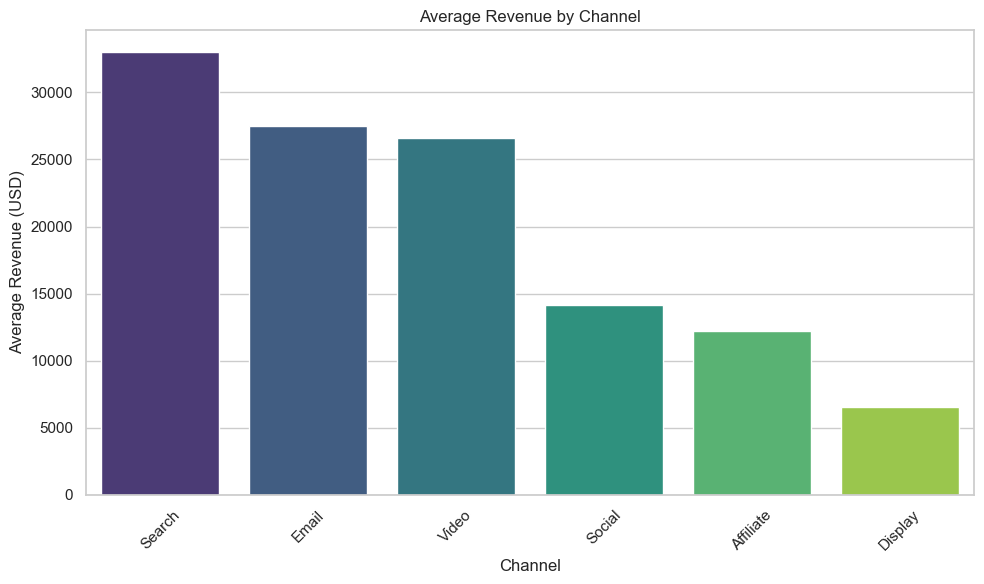

C:\Users\Saquire\AppData\Local\Temp\ipykernel_23620\4112217425.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y=performance_metric, data=region_perf, palette='magma')


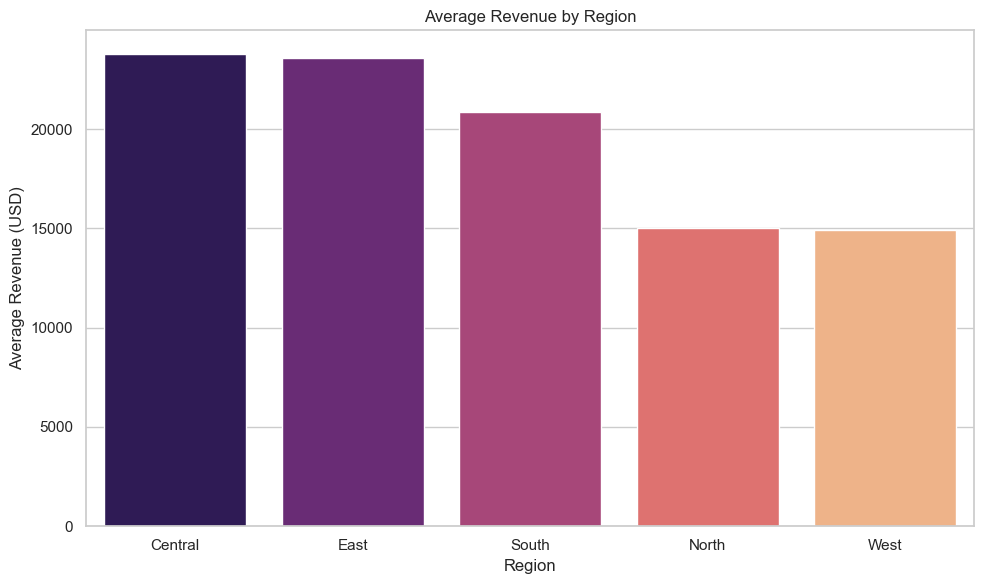

C:\Users\Saquire\AppData\Local\Temp\ipykernel_23620\4112217425.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device_type', y=performance_metric, data=device_perf, palette='rocket')


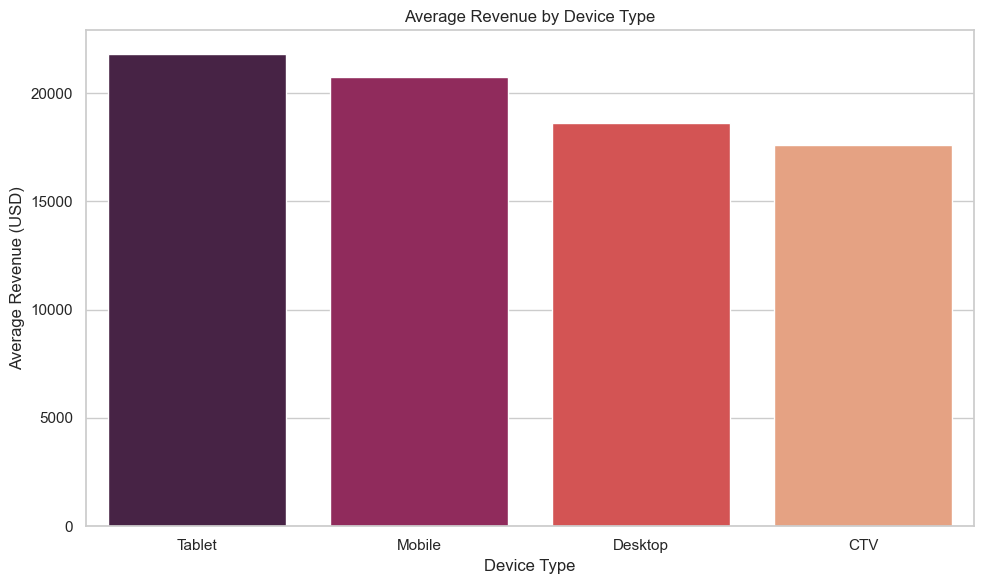

<Figure size 1400x800 with 0 Axes>

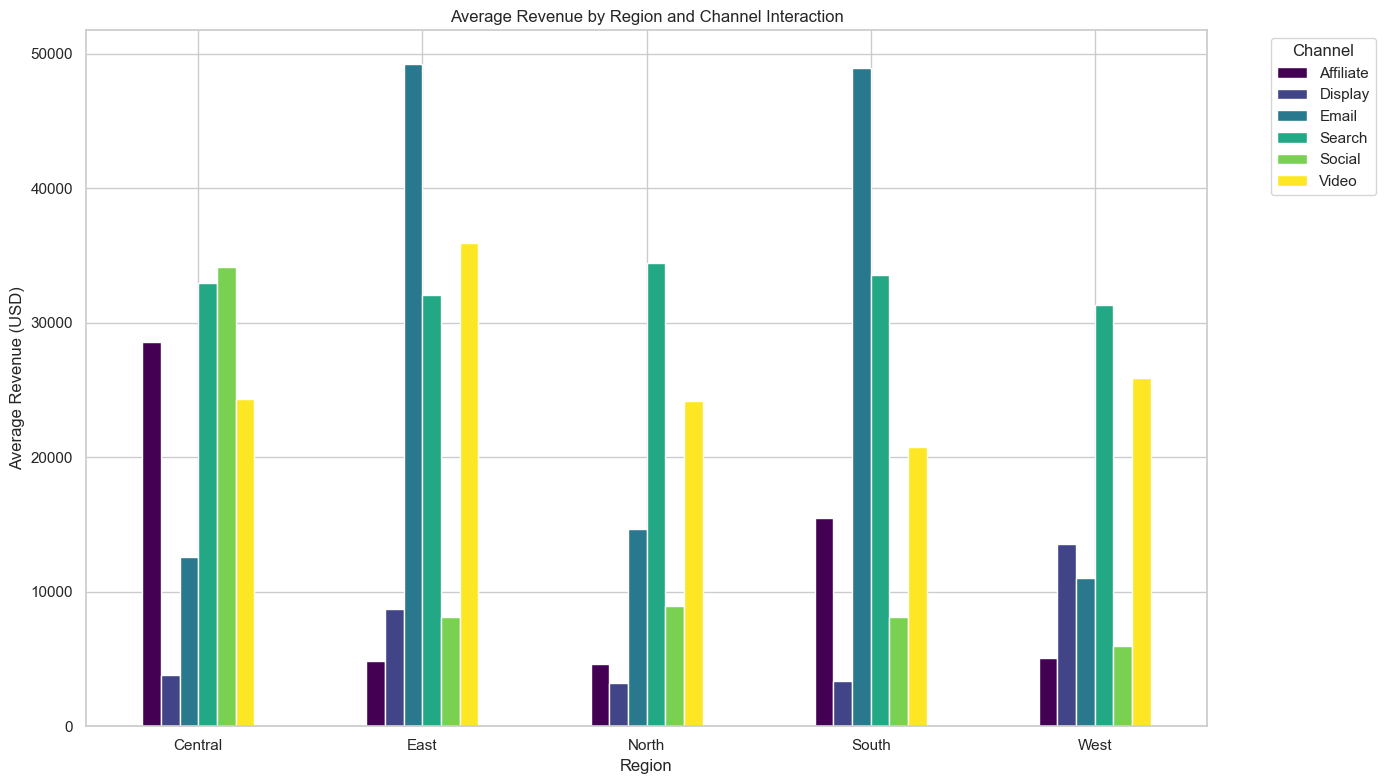

--- Performance Summary Statistics ---

Channel Averages (Sorted):
     channel   revenue_usd
0     Search  32975.365770
1      Email  27501.244390
2      Video  26582.979900
3     Social  14134.639742
4  Affiliate  12238.240375
5    Display   6555.809082

Region Averages (Sorted):
    region   revenue_usd
0  Central  23779.061209
1     East  23556.679319
2    South  20881.479651
3    North  15039.664332
4     West  14918.684410

Device Averages (Sorted):
  device_type   revenue_usd
0      Tablet  21807.412483
1      Mobile  20721.023861
2     Desktop  18603.562554
3         CTV  17582.337036


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('digital_media_cleaned.csv')

sns.set(style="whitegrid")
performance_metric = 'revenue_usd'

plt.figure(figsize=(10, 6))

channel_perf = df.groupby('channel')[performance_metric].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='channel', y=performance_metric, data=channel_perf, palette='viridis')
plt.title('Average Revenue by Channel')
plt.ylabel('Average Revenue (USD)')
plt.xlabel('Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
region_perf = df.groupby('region')[performance_metric].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='region', y=performance_metric, data=region_perf, palette='magma')
plt.title('Average Revenue by Region')
plt.ylabel('Average Revenue (USD)')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
device_perf = df.groupby('device_type')[performance_metric].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='device_type', y=performance_metric, data=device_perf, palette='rocket')
plt.title('Average Revenue by Device Type')
plt.ylabel('Average Revenue (USD)')
plt.xlabel('Device Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
pivot_data = df.groupby(['region', 'channel'])[performance_metric].mean().unstack()
pivot_data.plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Average Revenue by Region and Channel Interaction')
plt.ylabel('Average Revenue (USD)')
plt.xlabel('Region')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("--- Performance Summary Statistics ---")
print("\nChannel Averages (Sorted):")
print(channel_perf)

print("\nRegion Averages (Sorted):")
print(region_perf)

print("\nDevice Averages (Sorted):")
print(device_perf)

In [ ]:
df = pd.read_csv('digital_media_cleaned.csv')

print(df['channel'].unique())

print(df.select_dtypes(include=['object']).nunique())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 15:
        print(f"{col}: {unique_vals}")
    else:
        print(f"{col}: {len(unique_vals)} unique values")

['Affiliate' 'Social' 'Video' 'Search' 'Email' 'Display']
campaign_id           2394
date                   702
channel                  6
region                   5
device_type              4
audience_segment         4
campaign_objective       5
dtype: int64
campaign_id: 2394 unique values
date: 702 unique values
channel: ['Affiliate' 'Social' 'Video' 'Search' 'Email' 'Display']
region: ['North' 'South' 'Central' 'West' 'East']
device_type: ['Mobile' 'CTV' 'Tablet' 'Desktop']
audience_segment: ['Gen X' 'Gen Z' 'Millennials' 'Boomers']
campaign_objective: ['Traffic' 'App Installs' 'Awareness' 'Sales' 'Leads']


                      impressions    clicks   ctr_pct  spend_usd  conversions  \
impressions              1.000000  0.893649  0.098246   0.929725     0.879499   
clicks                   0.893649  1.000000  0.233209   0.887483     0.778054   
ctr_pct                  0.098246  0.233209  1.000000   0.238508     0.200042   
spend_usd                0.929725  0.887483  0.238508   1.000000     0.881403   
conversions              0.879499  0.778054  0.200042   0.881403     1.000000   
conversion_rate_pct      0.018041  0.048556  0.303953   0.091883     0.161554   
bounce_rate_pct          0.022328  0.017780  0.037359   0.029643     0.026459   
session_duration_sec    -0.023875 -0.029294 -0.031921  -0.014765    -0.014590   
audience_age             0.016799  0.019698 -0.001004   0.019741     0.007107   
ad_quality_score        -0.006756 -0.008063 -0.009259   0.007217    -0.001065   
revenue_usd              0.812322  0.778705  0.214279   0.761285     0.793187   

                      conve

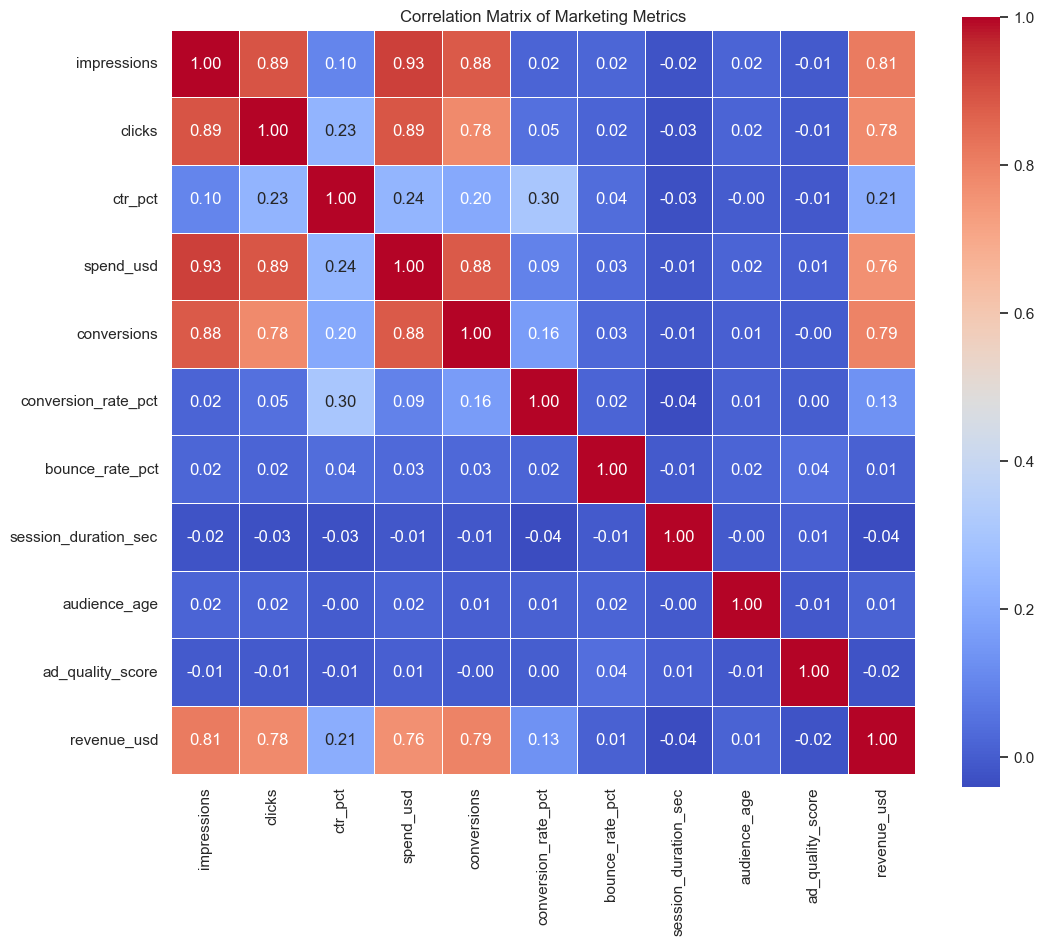

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('digital_media_cleaned.csv')
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.dropna().corr()
print(corr_matrix)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Marketing Metrics')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('digital_media_cleaned.csv')

Q1, Q3 = df['revenue_usd'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['revenue_usd'] >= lower_bound) & (df['revenue_usd'] <= upper_bound)].copy()

df_encoded = pd.get_dummies(df_clean, columns=['channel', 'region', 'device_type', 
                                               'audience_segment', 'campaign_objective'], 
                            drop_first=True)

X = df_encoded.drop(columns=['campaign_id', 'date', 'revenue_usd'])
y = df_encoded['revenue_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("--- Train Metrics ---")
print(f"R2: {train_r2:.4f}")
print(f"RMSE: ${train_rmse:.2f}")
print("\n--- Test Metrics ---")
print(f"R2: {test_r2:.4f}")
print(f"RMSE: ${test_rmse:.2f}")

X_all_scaled = scaler.transform(X)
df_clean['predicted_revenue_usd'] = model.predict(X_all_scaled)
df_clean.to_csv('digital_media_regression_results.csv', index=False)

--- Train Metrics ---
R2: 0.8171
RMSE: $4366.23

--- Test Metrics ---
R2: 0.7911
RMSE: $4744.47


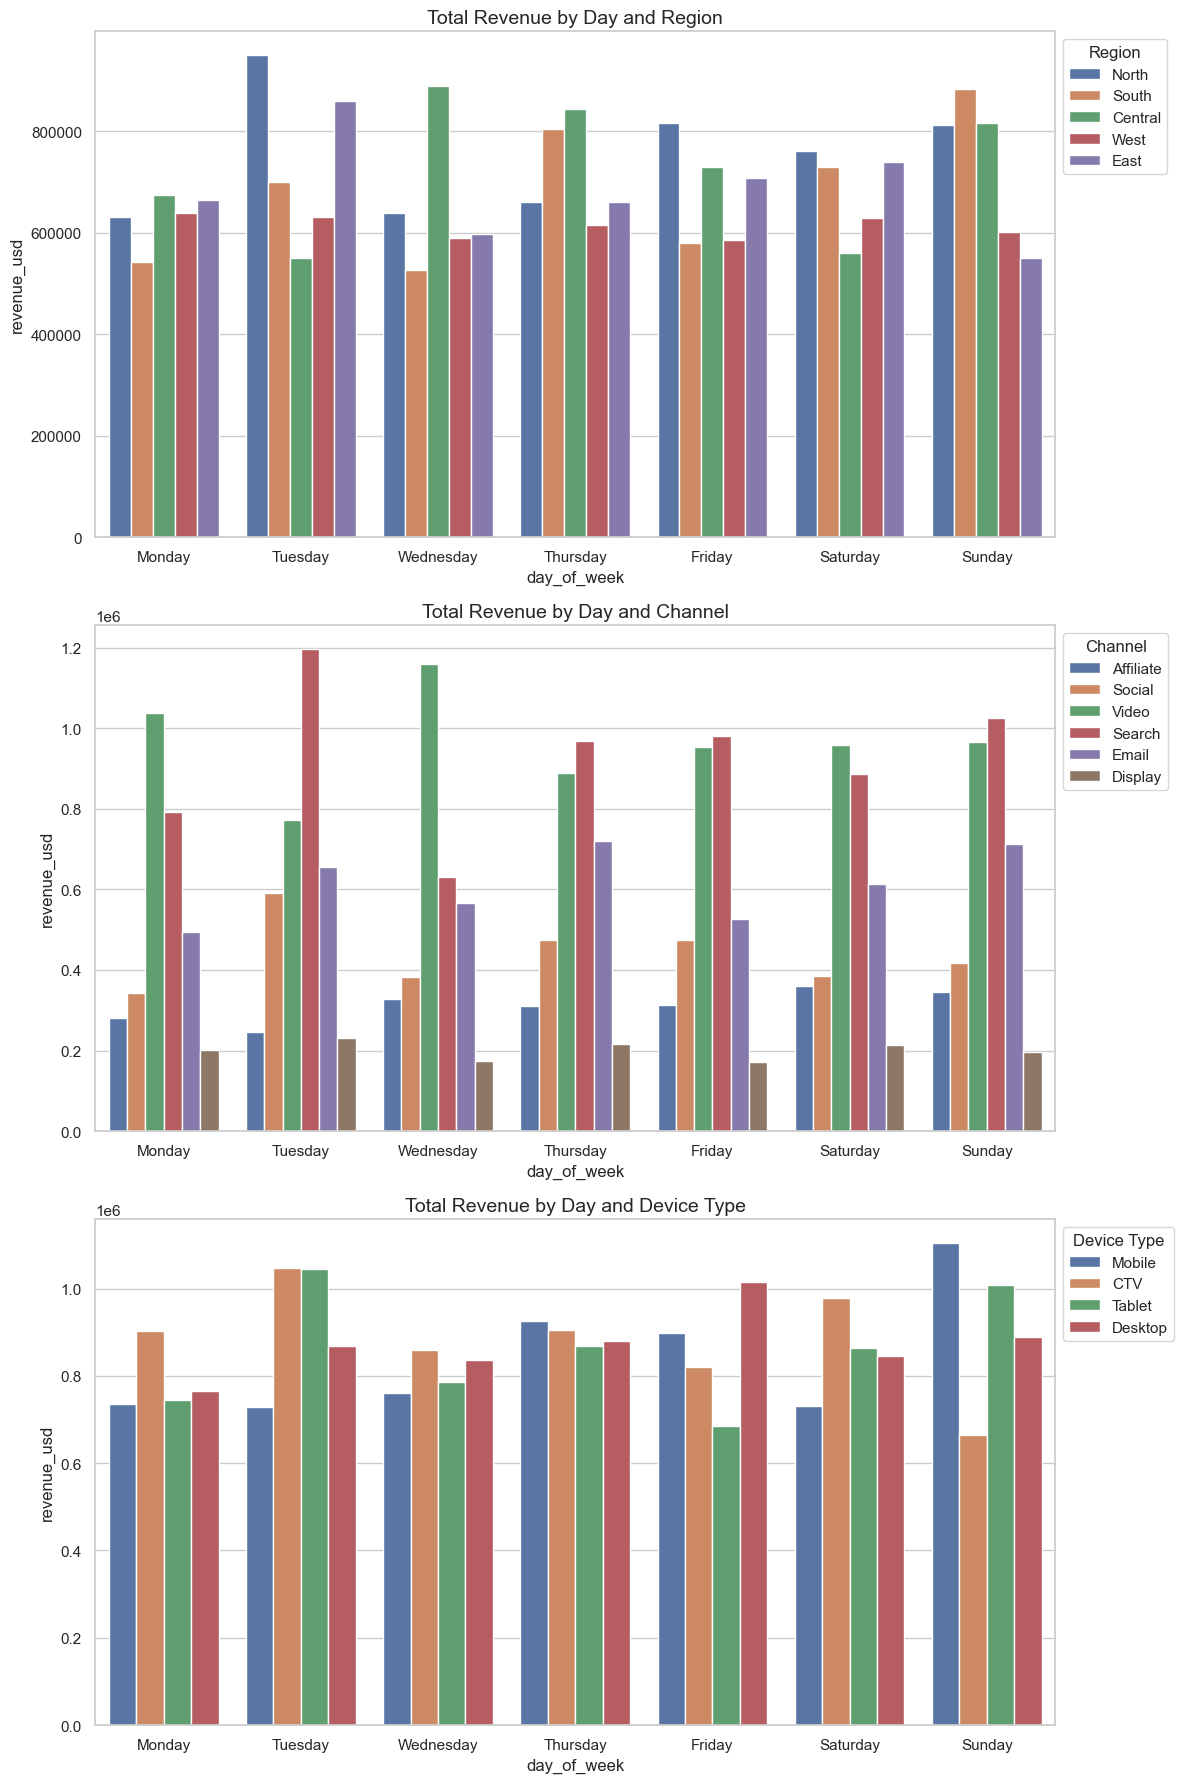

In [35]:

# 1. Load the dataset with day names
df = pd.read_csv('digital_media_with_days.csv')

# 2. Ensure days are in chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# 3. Create a multi-plot figure
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Graph 1: Day of Week vs Region
sns.barplot(data=df, x='day_of_week', y='revenue_usd', hue='region', 
            estimator=sum, errorbar=None, ax=axes[0])
axes[0].set_title('Total Revenue by Day and Region', fontsize=14)
axes[0].legend(title='Region', bbox_to_anchor=(1, 1))

# Graph 2: Day of Week vs Channel
sns.barplot(data=df, x='day_of_week', y='revenue_usd', hue='channel', 
            estimator=sum, errorbar=None, ax=axes[1])
axes[1].set_title('Total Revenue by Day and Channel', fontsize=14)
axes[1].legend(title='Channel', bbox_to_anchor=(1, 1))

# Graph 3: Day of Week vs Device Type
sns.barplot(data=df, x='day_of_week', y='revenue_usd', hue='device_type', 
            estimator=sum, errorbar=None, ax=axes[2])
axes[2].set_title('Total Revenue by Day and Device Type', fontsize=14)
axes[2].legend(title='Device Type', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('day_analysis_breakdown.png')

REGRESSOSR XGBOOST

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error


df = pd.read_csv('modified_digital_media_with_business_segment.csv')


X = df.drop(columns=['campaign_id', 'date', 'revenue_usd'], errors='ignore')
y = df['revenue_usd']


for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model1 = XGBRegressor(
    subsample=0.6,
    reg_lambda=2,
    reg_alpha=1,
    n_estimators=1500,
    min_child_weight=3,
    max_depth=2,
    learning_rate=0.01,
    gamma=0.5,
    colsample_bytree=1.0,
    colsample_bynode=0.8,
    colsample_bylevel=0.8,

    random_state=42,
    objective='reg:squarederror',
    enable_categorical=True
)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model1,
    X_train,
    y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

val_r2 = cv_scores.mean()


best_model1.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = best_model1.predict(X_train)
y_test_pred = best_model1.predict(X_test)


train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n" + "="*60)
print(f"{'Metric':<25} | {'R2 Score':<10} | {'RMSE':<10}")
print("-" * 60)

print(f"{'Training':<25} | {train_r2:.4f}     | {train_rmse:.2f}")
print(f"{'Validation (5-Fold CV)':<25} | {val_r2:.4f}     | N/A")
print(f"{'Test':<25} | {test_r2:.4f}     | {test_rmse:.2f}")

print("="*60)


print("\nCV Scores:", cv_scores)
print(f"CV Mean: {cv_scores.mean():.4f}")
print(f"CV Std Dev: {cv_scores.std():.4f}")


Metric                    | R2 Score   | RMSE      
------------------------------------------------------------
Training                  | 0.9224     | 2843.40
Validation (5-Fold CV)    | 0.8813     | N/A
Test                      | 0.8800     | 3596.32

CV Scores: [0.8397552  0.90005068 0.87726924 0.89815647 0.89149972]
CV Mean: 0.8813
CV Std Dev: 0.0223


CLASSIFIER XGBOOST

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score


df = pd.read_csv('modified_digital_media_with_business_segment.csv')


target_col = 'performance_tier_index'

X = df.drop(columns=[
    target_col,
    'campaign_id',
    'day',
    'performance_segment'
], errors='ignore')

y = df[target_col]


if y.dtype == 'object':
    y = y.astype('category').cat.codes

for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model = XGBClassifier(
    subsample=1.0,
    reg_lambda=2,
    reg_alpha=1,
    n_estimators=1000,
    min_child_weight=3,
    max_depth=2,
    learning_rate=0.02,
    gamma=0.5,
    colsample_bytree=1.0,
    
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    enable_categorical=True
)

from sklearn.model_selection import StratifiedKFold, cross_val_score


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1
)

val_acc = cv_scores.mean()

print("\nCV Scores (5-Fold):", cv_scores)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)


y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)


train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred, average='macro')
test_precision = precision_score(y_test, y_test_pred, average='macro')

train_recall = recall_score(y_train, y_train_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')

print("\n" + "="*65)
print(f"{'Metric':<20} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10}")
print("-"*65)

print(f"{'Training':<20} | {train_acc:.4f}   | {train_precision:.4f}   | {train_recall:.4f}")
print(f"{'Validation (CV)':<20} | {val_acc:.4f}   | {'N/A':<10} | {'N/A':<10}")
print(f"{'Test':<20} | {test_acc:.4f}   | {test_precision:.4f}   | {test_recall:.4f}")

print("="*65)


CV Scores (5-Fold): [0.91876751 0.85434174 0.90196078 0.89355742 0.88483146]


c:\Users\Saquire\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:42:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Metric               | Accuracy   | Precision  | Recall    
-----------------------------------------------------------------
Training             | 0.9602   | 0.9678   | 0.9563
Validation (CV)      | 0.8907   | N/A        | N/A       
Test                 | 0.9105   | 0.9118   | 0.9157


SHAP FOR XGBOOST REGRESSOR

In [3]:
import shap
import matplotlib.pyplot as plt


X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

for col in X_train_shap.select_dtypes(include=['category', 'object']).columns:
    X_train_shap[col] = X_train_shap[col].cat.codes
    X_test_shap[col] = X_test_shap[col].cat.codes


explainer = shap.TreeExplainer(best_model1)


X_sample = X_test_shap.sample(200, random_state=42)


shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

shap.summary_plot(shap_values, X_sample, plot_type="bar")


shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)

c:\Users\Saquire\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoostError: [22:42:49] C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (3800 vs. 4000) : 

XGBOOST CLASSIFIER

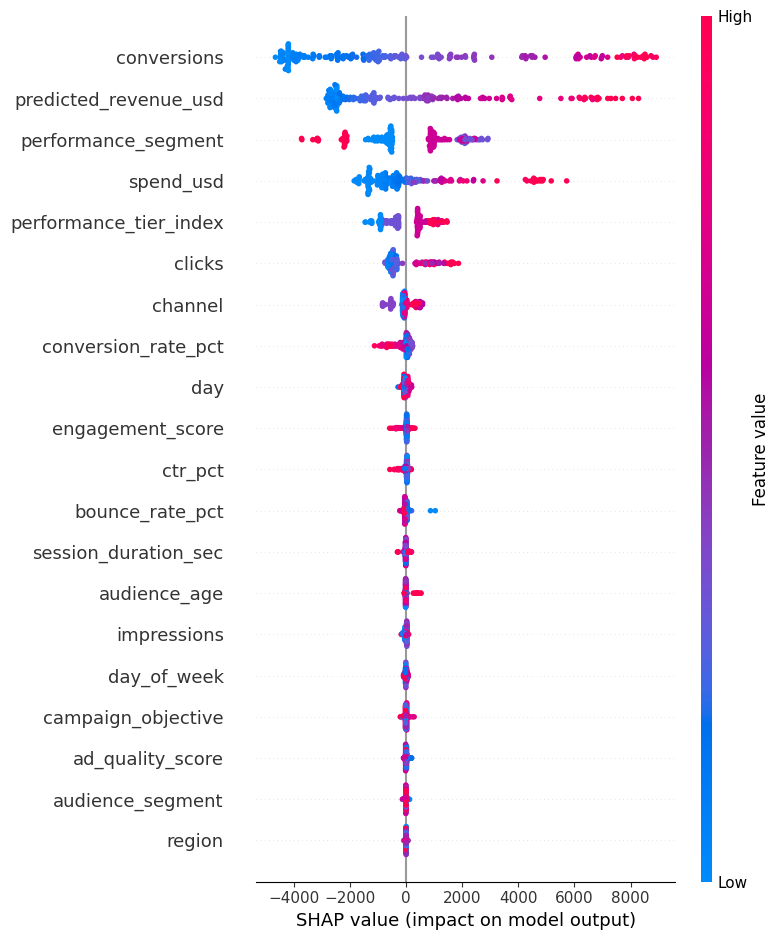

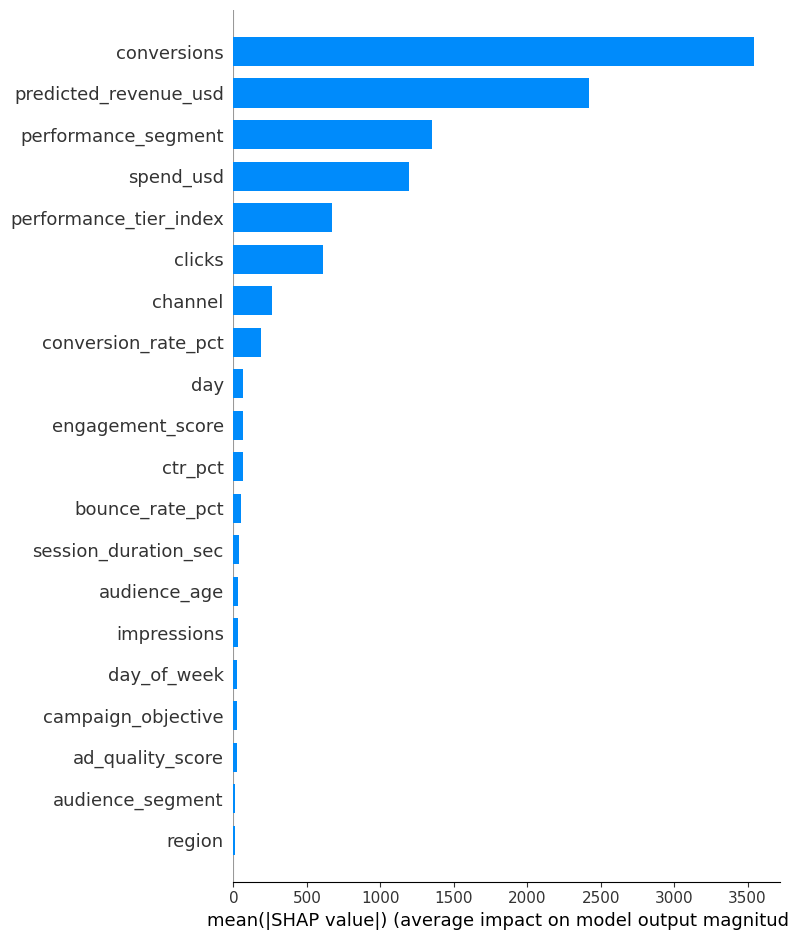

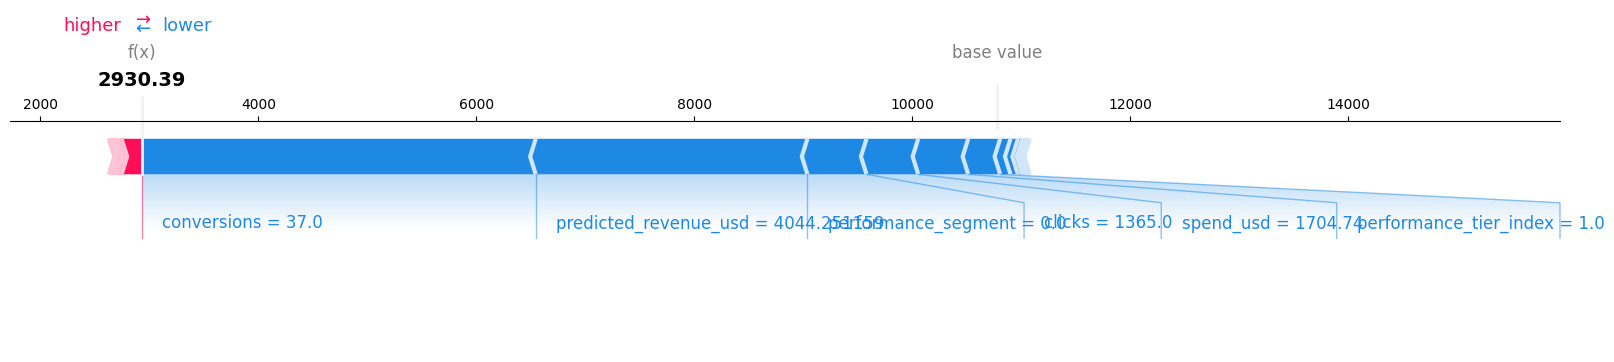

In [ ]:
import shap
import matplotlib.pyplot as plt


X_train_shap = X_train.copy()
X_test_shap = X_test.copy()


for col in X_train_shap.select_dtypes(include=['category', 'object']).columns:
    X_train_shap[col] = X_train_shap[col].cat.codes
    X_test_shap[col] = X_test_shap[col].cat.codes


explainer = shap.TreeExplainer(best_model)


X_sample = X_test_shap.sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)


shap.summary_plot(shap_values, X_sample)


shap.summary_plot(shap_values, X_sample, plot_type="bar")

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True
)